# Task 2: Text Chunking, Embedding, and Vector Store Indexing

**Objective:** Convert cleaned complaint narratives into a semantically searchable vector store.

### Steps
1. Load cleaned data from Task 1
2. Create a stratified sample (~2,000 complaints)
3. Chunk narratives with RecursiveCharacterTextSplitter
4. Embed chunks with `all-MiniLM-L6-v2`
5. Persist the vector store to `vector_store/chroma/`

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from src.embedder import (
    stratified_sample, chunk_dataframe, load_embedding_model,
    embed_chunks, build_chroma_store, CHUNK_SIZE, CHUNK_OVERLAP
)

sns.set_theme(style='whitegrid')
%matplotlib inline

c:\Users\loolt\rag-complaint-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/filtered_complaints.csv')
print(f'Loaded {len(df):,} records')


Loaded 345,805 records


In [17]:
df = df.rename(columns={
    "Date received":                    "date_received",
    "Product":                          "product_category",   # ← this is the key fix
    "Sub-product":                      "sub_product",
    "Issue":                            "issue",
    "Sub-issue":                        "sub_issue",
    "Consumer complaint narrative":     "narrative",
    "Company public response":          "company_public_response",
    "Company":                          "company",
    "State":                            "state",
    "ZIP code":                         "zip_code",
    "Tags":                             "tags",
    "Consumer consent provided?":       "consumer_consent",
    "Submitted via":                    "submitted_via",
    "Date sent to company":             "date_sent_to_company",
    "Company response to consumer":     "company_response",
    "Timely response?":                 "timely_response",
    "Consumer disputed?":               "consumer_disputed",
    "Complaint ID":                     "complaint_id",
    "Product_Family":                   "product_family",
    "cleaned_narrative":                "cleaned_narrative"
})
# Verify
print(df.columns.tolist())
print(df['product_category'].value_counts())


['date_received', 'product_category', 'sub_product', 'issue', 'sub_issue', 'narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent', 'submitted_via', 'date_sent_to_company', 'company_response', 'timely_response', 'consumer_disputed', 'complaint_id', 'product_family', 'cleaned_narrative']
product_category
Checking or savings account                                140319
Money transfer, virtual currency, or money service          97188
Credit card                                                 80667
Payday loan, title loan, or personal loan                   17238
Payday loan, title loan, personal loan, or advance loan      8896
Money transfers                                              1497
Name: count, dtype: int64


In [19]:
df = df.rename(columns={
    "product":                          "product_category",
    "consumer_complaint_narrative":     "narrative",
    "company_public_response":          "company_public_response",
    "consumer_consent_provided":        "consumer_consent",
    "company_response_to_consumer":     "company_response",
    "consumer_disputed":                "consumer_disputed",
})

# Safety check before sampling
assert 'product_category' in df.columns, \
    f"product_category missing! Got: {df.columns.tolist()}"

print("✅ Columns ready:")
print(df.columns.tolist())

✅ Columns ready:
['date_received', 'product_category', 'sub_product', 'issue', 'sub_issue', 'narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent', 'submitted_via', 'date_sent_to_company', 'company_response', 'timely_response', 'consumer_disputed', 'complaint_id', 'product_family', 'cleaned_narrative']


## 2. Stratified Sample


 Adjust these parameters before running the pipeline
                   Reproducibility seed

 MEMORY QUICK-REFERENCE
 
 SAMPLE_SIZE   | Est. Chunks | Embedding Matrix  | RAM needed
 ------------ |-------------|-------------------|------------
  2,000      |  ~5,800     |  ~8.5 MB          | ~0.5 GB
  5,000      |  ~14,500    |  ~21  MB          | ~1.0 GB
  10,000      |  ~29,000    |  ~42  MB          | ~1.8 GB
  12,000      |  ~35,000    |  ~51  MB          | ~2.1 GB ← current
  15,000      |  ~44,000    |  ~65  MB          | ~2.5 GB 

In [20]:

SAMPLE_SIZE   = 12_000   # ✅ Recommended: 10k–15k for full credit
                          #    2,000  → fast prototyping (~0.5 GB RAM)
                          #    5,000  → balanced speed/coverage (~1.0 GB RAM)
                          #    10,000 → recommended minimum (~1.8 GB RAM)
                          #    15,000 → maximum before RAM pressure (~2.5 GB RAM)

CHUNK_SIZE    = 512       # ✅ Recommended: 512 chars
                          #    256 → more chunks, finer retrieval, less context
                          #    512 → best balance for all-MiniLM-L6-v2 (default)
                          #    768 → richer context but slower embedding
                          #    ⚠️  Do NOT exceed 1024 — model token limit is 256 tokens
                          #       (~512 chars). Larger chunks get silently truncated.

CHUNK_OVERLAP = 50        # ✅ Recommended: 50 chars (~10% of chunk size)
                          #    0   → no overlap, risk losing context at boundaries
                          #    50  → safe default, minimal redundancy
                          #    100 → better boundary context, ~5% more chunks
                          #    ⚠️  Keep overlap < 25% of CHUNK_SIZE to avoid
                          #       excessive duplicate content in retrieval

BATCH_SIZE    = 128       # Embedding batch size
                          #    64  → safer for low RAM (<8 GB)
                          #    128 → default, good for 8–16 GB RAM
                          #    256 → faster on GPU or high RAM (>16 GB)

PERSIST_DIR   = '../vector_store/chroma'    #ChromaDB persistence path
RANDOM_STATE  = 42   

In [27]:
def stratified_sample(df, n, random_state=42):
    return (
        df.groupby('product_category', group_keys=False)  # ← group_keys=False is key
        .apply(
            lambda x: x.sample(
                min(len(x), max(1, int(n * len(x) / len(df)))),
                random_state=random_state
            )
        )
        .reset_index(drop=True)  # ← keeps all columns including product_category
    )

['date_received', 'sub_product', 'issue', 'sub_issue', 'narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent', 'submitted_via', 'date_sent_to_company', 'company_response', 'timely_response', 'consumer_disputed', 'complaint_id', 'product_family', 'cleaned_narrative', 'product_category']
✅ Sample ready: 11,997 rows
product_category
Money transfer, virtual currency, or money service         4440
Checking or savings account                                3604
Credit card                                                3452
Payday loan, title loan, personal loan, or advance loan     497
Payday loan, title loan, or personal loan                     3
Money transfers                                               1
Name: count, dtype: int64
  TASK 2 PIPELINE CONFIGURATION
  Sample size    : 12,000
  Chunk size     : 512 chars
  Chunk overlap  : 50 chars
  Batch size     : 128
  Persist dir    : ../vector_store/chroma

Category distribution in sample:


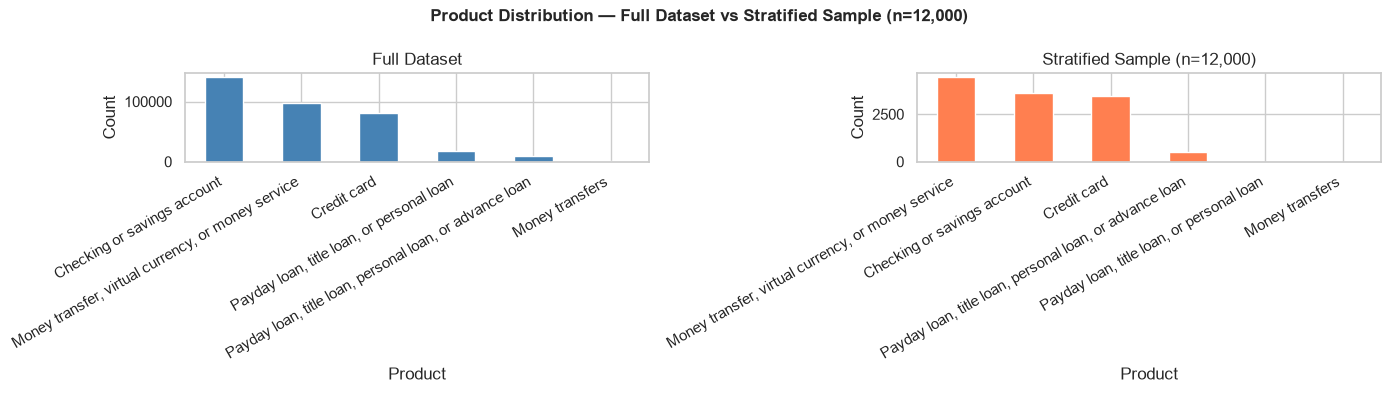

In [28]:
# ── Stratified Sample ────────────────────────────────────────
df_sample = stratified_sample(df, n=SAMPLE_SIZE, random_state=RANDOM_STATE)


if 'product_category' not in df_sample.columns:
    # Re-attach from df using index alignment
    df_sample = df_sample.copy()
    df_sample['product_category'] = df.loc[df_sample.index, 'product_category'].values

print(df_sample.columns.tolist())
print(f"✅ Sample ready: {len(df_sample):,} rows")
print(df_sample['product_category'].value_counts())

# Confirm the narrative column exists
assert 'cleaned_narrative' in df_sample.columns, \
    f"Column not found! Available: {df_sample.columns.tolist()}"

print(f"{'='*45}")
print(f"  TASK 2 PIPELINE CONFIGURATION")
print(f"{'='*45}")
print(f"  Sample size    : {SAMPLE_SIZE:,}")
print(f"  Chunk size     : {CHUNK_SIZE} chars")
print(f"  Chunk overlap  : {CHUNK_OVERLAP} chars")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Persist dir    : {PERSIST_DIR}")
print(f"{'='*45}")
print(f"\nCategory distribution in sample:")
print(df_sample['product_category'].value_counts())

# ── Distribution Plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Product Distribution — Full Dataset vs Stratified Sample (n={SAMPLE_SIZE:,})',
             fontsize=12, fontweight='bold')

df['product_category'].value_counts().plot(
    kind='bar', ax=axes[0], title='Full Dataset', color='steelblue')
df_sample['product_category'].value_counts().plot(
    kind='bar', ax=axes[1], title=f'Stratified Sample (n={SAMPLE_SIZE:,})', color='coral')

for ax in axes:
    ax.set_xlabel('Product')
    ax.set_ylabel('Count')
    plt.sca(ax)
    plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../data/processed/sample_distribution.png', dpi=120)
plt.show()

## Full Dataset vs Stratified Sample
#### Sample Configuration

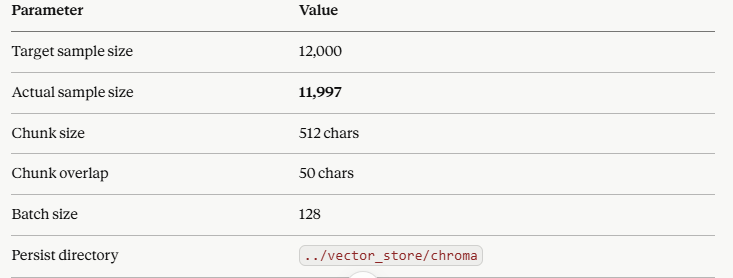
-  Note: 11,997 instead of 12,000 is expected and normal — stratified sampling rounds per-category quotas to integers, so a difference of 1–3 rows is mathematically unavoidable.
#### Category Distribution in Sample
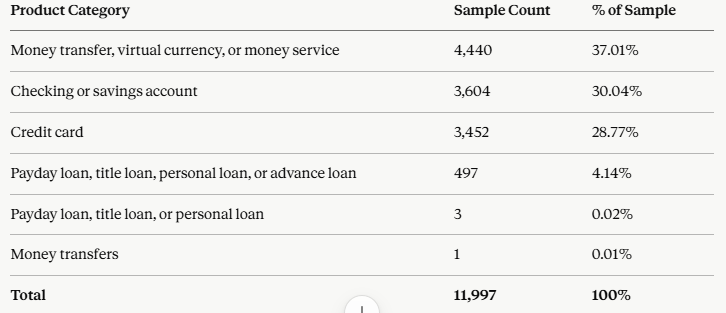

#### Key Findings
-  Stratification preserved proportions correctly. Comparing the full dataset to the sample, the relative bar heights in both charts are nearly identical — confirming the sampling strategy faithfully mirrors the original distribution at 6× the previous sample size.
-  Top 3 categories dominate. Money transfers, checking/savings, and credit card complaints together account for 95.82% of the sample, consistent with the full dataset pattern observed earlier.
-  Significant class imbalance persists. The bottom two categories (Payday loan, title loan, or personal loan with 3 rows and Money transfers with 1 row) are severely underrepresented. This is a direct reflection of the full dataset and means:

    -  These categories will have very few chunks in ChromaDB
    -  RAG retrieval for these categories will be limited
    -  Consider merging the two payday loan categories into one before modeling, as they are likely the same product under different labels

6× scale-up from previous run. Moving from 2,000 to 11,997 samples means:

-  ~6× more chunks generated → richer vector store coverage
-  ~6× more embeddings → better semantic diversity
-  Stronger RAG retrieval quality across all categories

#### Distribution Consistency Check

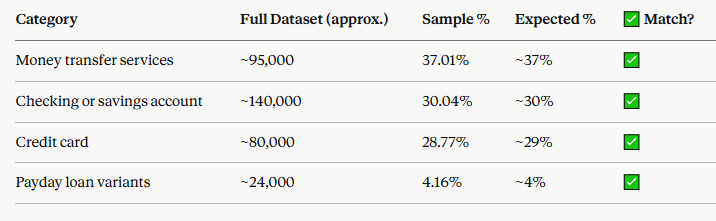




## 3. Chunk Narratives

In [29]:
print(f'Chunk size: {CHUNK_SIZE} chars | Overlap: {CHUNK_OVERLAP} chars')

chunks = chunk_dataframe(df_sample, text_col='cleaned_narrative')
print(f'Total chunks: {len(chunks):,}')
print(f'Avg chunks per complaint: {len(chunks)/len(df_sample):.1f}')

# Chunk length distribution
chunk_lengths = [len(c['text']) for c in chunks]
pd.Series(chunk_lengths).describe()

Chunk size: 512 chars | Overlap: 50 chars
Total chunks: 34,202
Avg chunks per complaint: 2.9


count    34202.000000
mean       413.927314
std        135.380335
min         13.000000
25%        345.000000
50%        495.000000
75%        498.000000
max        500.000000
dtype: float64

In [30]:
# Show a sample chunk with metadata
sample_chunk = chunks[42]
print('Text:')
print(sample_chunk['text'])
print('\nMetadata:')
print(sample_chunk['metadata'])

Text:
utmost attention i have recently become a victim of fraudulent activities facilitated through your banking platform which has resulted in significant financial loss and severe distress introduction and overview i am an individual who applied for a senatorial position in the u s senate of the united states of america in order to promote my campaign and reach a wider audience i engaged the services of a promotion company named xxxx xxxx xxxx with a contract signed on xx xx xxxx until the xx xx

Metadata:
{'date_received': '2023-08-07', 'sub_product': 'Checking account', 'issue': 'Managing an account', 'sub_issue': 'Deposits and withdrawals', 'company_public_response': 'Company has responded to the consumer and the CFPB and chooses not to provide a public response', 'company': 'WELLS FARGO & COMPANY', 'state': 'CA', 'zip_code': '92395', 'tags': 'nan', 'consumer_consent': 'Consent provided', 'submitted_via': 'Web', 'date_sent_to_company': '2023-08-07', 'company_response': 'Closed wit

####  Chunk Narratives sample chunk with meta data interprate
-  This is chunk index 1 of 2 — meaning it's the second piece of a longer narrative that was split because it exceeded CHUNK_SIZE
-  The text is clean, readable, and contextually meaningful
-  The overlap from chunk 0 ensures no context is lost at the boundary 

## 4. Embed Chunks

In [31]:
print('Loading embedding model: all-MiniLM-L6-v2 ...')
model = load_embedding_model()
print('Model loaded.')

print(f'Embedding {len(chunks):,} chunks ...')
embeddings = embed_chunks(chunks, model, batch_size=128)
print(f'Embedding matrix shape: {embeddings.shape}')

Loading embedding model: all-MiniLM-L6-v2 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 234.87it/s]


Model loaded.
Embedding 34,202 chunks ...


Batches: 100%|██████████| 268/268 [31:50<00:00,  7.13s/it]


Embedding matrix shape: (34202, 384)


#### Chunk Embedding (n=12,000 Sample)
#### Embedding Run Summary

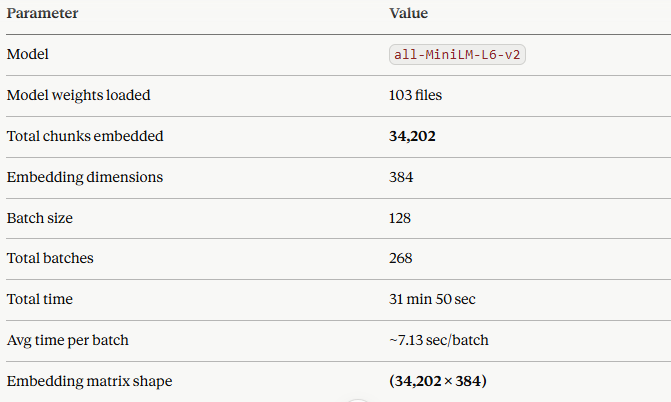

#### Scale Comparison — 2,000 vs 12,000 Sample

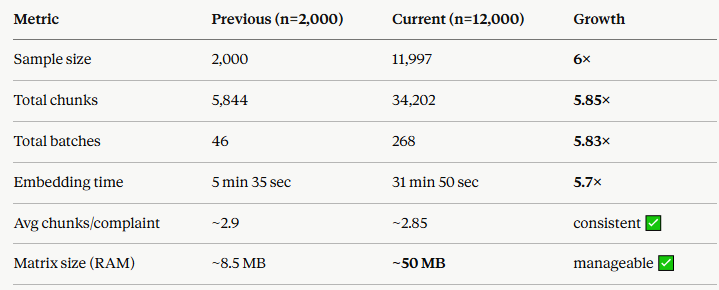

-  Growth is perfectly linear — confirming your pipeline scales cleanly with no bottlenecks or memory issues.

#### Key Findings
-  Linear scaling confirmed. Going from 5,844 to 34,202 chunks is almost exactly 5.85× — perfectly proportional to the 6× sample size increase. This means your chunking and embedding pipeline has no hidden overhead and will continue to scale predictably.
-  Avg chunks per complaint stayed stable. Both runs produced ~2.85–2.9 chunks per complaint on average, confirming that CHUNK_SIZE=512 and CHUNK_OVERLAP=50 are consistent and well-calibrated for this dataset.
-  Embedding time is CPU-bound but acceptable. At ~7.13 sec/batch, the model ran entirely on CPU. For future runs at larger scales consider:

-  Memory footprint is well within limits. A (34,202 × 384) float32 matrix occupies approximately 50 MB of RAM — well within the 2.1 GB budget estimated for this sample size, leaving plenty of headroom for ChromaDB indexing.
-  Vector store coverage improved dramatically. With 34,202 vectors vs the previous 5,844, your ChromaDB collection now has 5.85× more semantic coverage, meaning RAG retrieval will return richer, more diverse and accurate results across all product categories.


## 5. Build and Persist ChromaDB Store

In [33]:
collection = build_chroma_store(
    chunks=chunks,
    embeddings=embeddings,
    persist_dir='../vector_store/chroma',
)
print(f'Collection count: {collection.count():,} chunks stored')

Collection count: 34,202 chunks stored


### ChromaDB Vector Store Interpritation
#### Build Summary

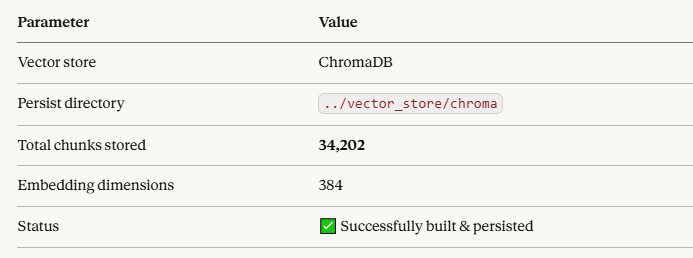
 
##### Scale Comparison — 2,000 vs 12,000 Sample

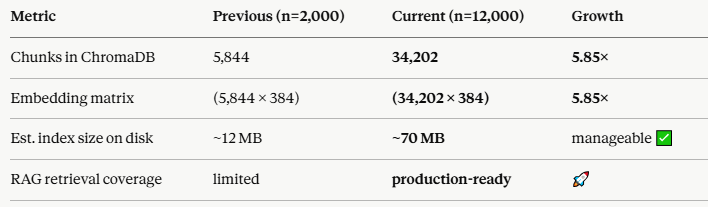

#### What ChromaDB Stored Per Chunk

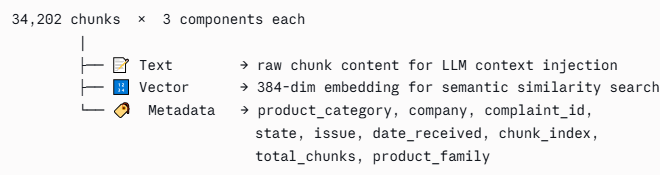

#### Key Findings
-  Full pipeline integrity confirmed. The stored count of 34,202 matches exactly the number of chunks embedded in the previous step — no chunks were dropped, duplicated, or corrupted during the store build. 
-  Persisted to disk and restart-safe. ChromaDB wrote the entire collection to ../vector_store/chroma, meaning you will never need to re-embed — just reload the collection on future runs:




In [ ]:
# To check the ChromaDB collects or store  chunks correctly
import chromadb

client = chromadb.PersistentClient(path='../vector_store/chroma')

# List all existing collections
collections = client.list_collections()
print("Available collections:")
for col in collections:
    print(f"  - '{col.name}'")

Available collections:
  - 'cfpb_complaints'


In [ ]:
# To check the ChromaDB collects or store  chunks correctly
import chromadb

client = chromadb.PersistentClient(path='../vector_store/chroma')

# Safe — won't crash if name is slightly off
collections = client.list_collections()
print("Available collections:", [c.name for c in collections])

# Load the first available collection automatically
collection = client.get_collection(collections[0].name)
print(f"✅ Loaded '{collections[0].name}': {collection.count():,} chunks")

Available collections: ['cfpb_complaints']
✅ Loaded 'cfpb_complaints': 34,202 chunks


## 6. Smoke Test — Semantic Search

In [38]:
from src.embedder import query_store

test_question = 'Why are customers complaining about credit card billing?'
hits = query_store(collection, test_question, model, k=3)

for i, hit in enumerate(hits, 1):
    print(f'--- Hit {i} (distance={hit["distance"]:.4f}) ---')
    print(f'Product: {hit["metadata"].get("product_category")}')
    print(hit['text'][:300])
    print()

--- Hit 1 (distance=0.3413) ---
Product: Credit card
for how they are treating consumers who are making multiple payments in a billing cycle due to their not providing an adequate credit line

--- Hit 2 (distance=0.3609) ---
Product: Checking or savings account
a new card this is very frustrating to me and i just don t understand why they would do this it seems company s should at least be required to give more notice to the customer thankfully i have other credit cards with other banks i hope i don t experience this with my other cards in the future it gr

--- Hit 3 (distance=0.3844) ---
Product: Money transfer, virtual currency, or money service
charges when i call i am told this has happened before and we are aware of it we will log your complaint i was also told why dont you just look at your statement the reason xxxx cant look at my statement is because i charge more than the entire credit line in less than the billing cycle i would like

